In [1]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sm import NeuralNet, LearnableActivationFunc, LearnableActivationFuncChunk, LearnableActivationFuncShared
from sm import LearnableActivationFunc
from models import CondSM

def set_seed(seed: int, deterministic: bool = False):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        # More reproducible, sometimes slower
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        # Faster, may vary slightly run-to-run
        torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_ds  = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
len(train_ds), len(test_ds)

(60000, 10000)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


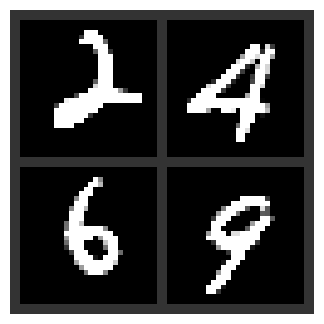

In [3]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

batch = next(iter(train_loader))
imgs, labels = batch

grid = make_grid(imgs[:4], nrow=2, padding=2, pad_value=0.2)  # (C, H, W)
fig, ax = plt.subplots(figsize=(4, 4))

ax.set_position([0.18, 0.12, 0.76, 0.83])

ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
ax.axis("off")

plt.savefig('mnist_data.pdf')
plt.show()

In [4]:
data_type = 'uni_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

model.eval()
for p in model.parameters():
    p.requires_grad_(False)
model = model.to(device)   # move once here

class SmallCNN(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 28x28 -> 28x28
        self.pool  = nn.MaxPool2d(2, 2)                # 28x28 -> 14x14
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)   # 14x14 -> 14x14
        self.fc1   = nn.Linear(32 * 14 * 14, 64)
        self.fc2   = nn.Linear(64, 10)

        self.act1 = LearnableActivationFuncShared(model, 3, -1.5, 1.5, None)
        self.act2 = LearnableActivationFuncShared(model, 3, -1.5, 1.5, None)
        self.act3 = LearnableActivationFuncShared(model, 3, -1.5, 1.5, None)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # Optional: make last layer a bit smaller so logits don't start huge
        nn.init.xavier_uniform_(self.fc2.weight, gain=1.0)
        if self.fc2.bias is not None:
            nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        return x

import torch
import torch.nn as nn
import torch.nn.functional as F

class DeeperCNN(nn.Module):
    def __init__(self, model):
        super().__init__()

        # 28x28
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),   # 28x28
            nn.BatchNorm2d(32),
            LearnableActivationFuncShared(model, 3, -1.5, 1.5, None),
            nn.Conv2d(32, 32, 3, padding=1),  # 28x28
            nn.BatchNorm2d(32),
            LearnableActivationFuncShared(model, 3, -1.5, 1.5, None),
            nn.MaxPool2d(2, 2),               # 14x14
            nn.Dropout2d(0.10),
        )

        # 14x14
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),  # 14x14
            nn.BatchNorm2d(64),
            LearnableActivationFuncShared(model, 3, -1.5, 1.5, None),
            nn.Conv2d(64, 64, 3, padding=1),  # 14x14
            nn.BatchNorm2d(64),
            LearnableActivationFuncShared(model, 3, -1.5, 1.5, None),
            nn.MaxPool2d(2, 2),               # 7x7
            nn.Dropout2d(0.15),
        )

        # 7x7
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), # 7x7
            nn.BatchNorm2d(128),
            LearnableActivationFuncShared(model, 3, -1.5, 1.5, None),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.BatchNorm1d(256),
            LearnableActivationFuncShared(model, 3, -1.5, 1.5, None),
            nn.Dropout(0.30),
            nn.Linear(256, 10),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # Keep logits sane at init
        last = self.head[-1]
        if isinstance(last, nn.Linear):
            nn.init.xavier_uniform_(last.weight, gain=1.0)
            if last.bias is not None:
                nn.init.zeros_(last.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.head(x)
        return x

net = SmallCNN(model).to(device)
#net = DeeperCNN(model).to(device)
sum(p.numel() for p in net.parameters())

424671

In [5]:
for seed in [0, 1, 2, 3, 4]:
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    EPOCHS = 10
    training_loss = []
    test_accuracies = []
    for epoch in range(1, EPOCHS+1):
        net.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            out = net(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    
        train_loss = running_loss / total
        train_acc = correct / total
        print(f'Training | Epoch {epoch}/{EPOCHS} | Loss: {train_loss:.4f} | Acc: {100. * train_acc:.4f}')
        
        net.eval()
        with torch.no_grad():
            running_loss = 0.0
            correct = 0
            total = 0
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = net(x)
    
                loss = criterion(out, y)
                running_loss += loss.item() * x.size(0)
                pred = out.argmax(1)
                correct += (pred == y).sum().item()
                total += y.size(0)
            print(f'Testing | Loss: {running_loss / total} | Acc: {100. * correct / total:.4f}')
            test_accuracies.append(100. * correct / total)
            training_loss.append(train_loss)
    
    torch.save({
            "model_state_dict": net.state_dict(),
            "test_accuracy": test_accuracies,
            "training_loss": training_loss
        }, f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/data_type={data_type}_mnist_seed={seed}_deeper.pth')

    print('seed:', seed)

Training | Epoch 1/10 | Loss: 2.3028 | Acc: 11.2000
Testing | Loss: 2.3018032653808596 | Acc: 11.3500
Training | Epoch 2/10 | Loss: 2.3019 | Acc: 11.1200
Testing | Loss: 2.301335062408447 | Acc: 11.3500
Training | Epoch 3/10 | Loss: 2.3021 | Acc: 11.1000
Testing | Loss: 2.3013434638977053 | Acc: 11.3500
Training | Epoch 4/10 | Loss: 2.3017 | Acc: 11.1783
Testing | Loss: 2.3017878017425537 | Acc: 11.3500
Training | Epoch 5/10 | Loss: 2.3019 | Acc: 11.1517
Testing | Loss: 2.3012886070251466 | Acc: 11.3500
Training | Epoch 6/10 | Loss: 2.3018 | Acc: 11.1300
Testing | Loss: 2.3017500785827636 | Acc: 11.3500
Training | Epoch 7/10 | Loss: 2.3020 | Acc: 11.2367
Testing | Loss: 2.301371385192871 | Acc: 11.3500
Training | Epoch 8/10 | Loss: 2.3019 | Acc: 11.1900
Testing | Loss: 2.3025094062805174 | Acc: 11.3500
Training | Epoch 9/10 | Loss: 2.3018 | Acc: 11.1100
Testing | Loss: 2.301957057571411 | Acc: 11.3500
Training | Epoch 10/10 | Loss: 2.3021 | Acc: 11.1617
Testing | Loss: 2.30135043830871

KeyboardInterrupt: 